---
title: "ANN training in PyTorch and hyperparameter tuning"
author: "Jorge Bris Moreno"
format:
  html:
    embed-resources: true
---

# Homework-2: 

`ANN training in Keras or Pytorch & Hyper-parameter tuning`

## Overview 

* Classification is one of the most common forms of supervised machine learning 
* In this homework we will explore "model tuning" for the case of a multi-class classification problem, as applied the MNIST data set
* `You can do this assignment in either Keras OR PyTorch` (or both), it is your choice.

## Submission 

* You need to upload TWO documents to Canvas when you are done
  * (1) A PDF (or HTML) of the completed form of the `HW-2.ipynb` document 
* The final uploaded version should NOT have any code-errors present 
* All outputs must be visible in the uploaded version, including code-cell outputs, images, graphs, etc

`IMPORTANT`: THERE ARE MANY WAYS TO DO THIS, SO FEEL FREE TO DEVIATE SLIGHTLY FROM THE EXACT DETAILS, BUT THE OVERALL RESULT AND FLOW SHOULD MATCH WHAT IS OUTLINED BELOW.

## Important Notes:

I printed the outputs as the runtimes were very long and it is common practice. Furthermore, even though it will be mentioned later, the gridsearch for the choice with l1 and l2 was done in a 5 by 5 grid instead of a 10 by 10 grid. Professor James said that it was okay to do so.

## HW-2.1: Data preparation

* Normalize the data as needed
* Partition data into training, validation, and test (i.e. leave one out CV)
  * One option to do this is to give these arrays global scope so they are seen inside the training function (so they don't need to be passed to functions)
* **Optional but recommended:** Create a K-fold cross validation data set, rather than just doing leave one out
* Do any other preprocessing you feel is needed

In [3]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader, random_split
from sklearn.model_selection import KFold
import numpy as np
import copy
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.init as init
from sklearn.model_selection import KFold
import copy
import pandas as pd
import seaborn as sns

In [4]:
# Download training data from open datasets.
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

# Download test data from open datasets.
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

# You can also create DataLoader instances for both datasets to easily iterate during training and validation
batch_size = 64
# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

In [5]:
# explore data-set object
print("\n TYPE:\n",type(training_data))
print("\n SUMMARY:\n",training_data)
print("\n ATTRIBUTES:\n",training_data.__dict__.keys())
print("\n FIRST DATA POINT:\n",)
img, label = training_data[0]
print(img.shape,label)
print(len(training_data))
# print(training_data.samples)


 TYPE:
 <class 'torchvision.datasets.mnist.FashionMNIST'>

 SUMMARY:
 Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

 ATTRIBUTES:
 dict_keys(['root', 'transform', 'target_transform', 'transforms', 'train', 'data', 'targets'])

 FIRST DATA POINT:

torch.Size([1, 28, 28]) 9
60000


In [6]:
# from demonstart data loader
# for X, y in test_dataloader:
for X, y in train_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


## HW-2.2: Generalized model

* Create a `General` model function (or class) that takes hyper-parameters and evaluates the model
  * The function should work with a set of hyper parameters than can be easily be controlled and varied by the user (for later parameter tuning)
  * This should work for the training, test, and validation set 
* Feel free to recycle code from the lab assignments and demo's  
* Use the deep learning best practices that we discussed in class. 
* Document what is going on in the code, as needed, with narrative markdown text between cells.

In [23]:
# Get cpu or gpu device for training.
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

# Define neural network
class NeuralNetwork(nn.Module):
    def __init__(self, input_size, layer_sizes, activation_funcs, dropout_rate=0.0, weight_init='random'):
        # Initialize neural network
        super(NeuralNetwork, self).__init__()
        # flatten the imput (as they are images)
        layers = [nn.Flatten()]
        # prev_size as size of previous imputs to track the next layer size
        prev_size = input_size

        # weight initialization
        def init_weights(layer):
            if weight_init == 'xavier':
                if isinstance(layer, nn.Linear):
                    init.xavier_uniform_(layer.weight)

        # loop through the layers or the network
        for i, size in enumerate(layer_sizes):
            # fully connected layers
            linear_layer = nn.Linear(prev_size, size)

            layers.append(linear_layer)
            
            # activation functions
            activation_func = activation_funcs[i]
            if activation_func == 'relu':
                layers.append(nn.ReLU())
            # sigmoid activation function as default for classification
            elif activation_func == 'sigmoid':
                layers.append(nn.Sigmoid())
            # add dropout layer if dropout rate is greater than 0
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            # set the size for the next layer
            prev_size = size
        
        # Output layer with 10 classes
        output_layer = nn.Linear(prev_size, 10) 

        # Initialize weights of output layer
        init_weights(output_layer)
        
        layers.append(output_layer)

        # Store layers in Sequential container
        self.model = nn.Sequential(*layers)
    # forward pass through the network
    def forward(self, X):
        return self.model(X)

# define model
def model_fn():
    return NeuralNetwork(input_size=28*28, layer_sizes=[512, 256], activation_funcs=['relu', 'relu'], dropout_rate=0.5)

Using cpu device


## HW-2.3: Model training function

* You can do this in either a function (or python class), or however you think is best. 
* **Create a training function** (or class) that takes hyper-parameter choices and trains the model
  * If you are doing "leave one out", your training function only needs to do one training per hyper-parameter choice
  * If you are doing K-fold cross validation, you should train the model K times for each hyper-parameter choice, and report the average result cross the training runs at the end (this is technically a better practice but requires more computation). 
  * Use a dense feed forward ANN model, with the correct output layer activation, and correct loss function
  * `You MUST use early stopping` inside the function, otherwise it defeats the point
  * **Have at least the following hyper-parameters as inputs to this function** 
    * L1 regularization constant, L2 regularization constant, dropout rate 
    * Learning rate
    * Weight Initialization: Fully random vs Xavier Weight Initialization
    * Hidden layer activation function choice (use relu, sigmoid, or tanh)
    * Number and size of ANN hidden layers 
    * Optimizer choice, have at least three included (Adam, SGD, or RmsProp)
    * You can wrap all of the hyper-parameter arguments into a dictionary, or do it however you want  
  * **Visualization**
    * Include a boolean parameter as a function input that controls whether visualization is created or not
    * If `true`, Monitor training and validation throughout training by plotting
    * Report a confusion matrix 
  * Return the final training and validation error (averaged if using K-fold)
    * again, you must use early stopping to report the best training/validation loss without over-fitting
* Depending how you do this, it can be a lot of computation, start small and scale up and consider using Co-lab 
  

In [17]:
# model evaluation
def evaluate_model(model, dataloader, loss_fn, device):
    # Set model to evaluation mode
    model.eval()
    # Initialize metrics
    total_loss, correct, total = 0, 0, 0
    # no gradients during evaluation (saving memory and computations)
    with torch.no_grad():
        # loop over batches of data
        for X, y in dataloader:
            # move data to device
            X, y = X.to(device), y.to(device)
            # predict on X
            outputs = model(X)
            # calculate loss
            loss = loss_fn(outputs, y)
            # extract and add loss to the total loss
            total_loss += loss.item()
            # calculate correct predictions
            correct += (outputs.argmax(1) == y).sum().item()
            # number of samples
            total += y.size(0)
    # return average loss and accuracy
    return total_loss / len(dataloader), correct / total

# train model
def training_model_kfold(k_folds, dataset, model_fn, loss_fn, optimizer_name, lr, l1_reg, l2_reg, num_epochs=100, device='cpu', plot=False, patience=4):
    # Divide into k folds
    kfold = KFold(n_splits=k_folds, shuffle=True)
    # Initialize metrics to store
    metrics_record = {'val_loss': [], 'val_accuracy': [], ['train_loss'] : []}

    # Loop through the folds
    for fold, (train_ids, test_ids) in enumerate(kfold.split(np.arange(len(dataset)))):
        print(f'FOLD {fold}')
        print('--------------------------------')

        # Reset early stopping and best model tracking for each fold
        early_stopping_wait_number = 0
        best_val_loss = np.inf
        best_model = None
        
        # Initialize plotting lists for each fold (plot=True only)
        fold_performance = {'train_loss': [], 'val_loss': [], 'val_accuracy': []} if plot else None

        # data loaders for training and testing data in this fold (better for batch processing)
        train_subsampler = torch.utils.data.SubsetRandomSampler(train_ids)
        test_subsampler = torch.utils.data.SubsetRandomSampler(test_ids)
        trainloader = torch.utils.data.DataLoader(dataset, batch_size=64, sampler=train_subsampler)
        testloader = torch.utils.data.DataLoader(dataset, batch_size=64, sampler=test_subsampler)

        # Initialize neural network
        model = model_fn().to(device)

        # Choose optimizer (added more as probably will be used in the future)
        optimizer = {
            "Adam": torch.optim.Adam(model.parameters(), lr=lr, weight_decay=l2_reg),
            "SGD": torch.optim.SGD(model.parameters(), lr=lr, weight_decay=l2_reg),
            "RMSProp": torch.optim.RMSprop(model.parameters(), lr=lr, weight_decay=l2_reg),
            "LBFGS": torch.optim.LBFGS(model.parameters(), lr=lr)
        }.get(optimizer_name, None)
        # raise flag if optimizer is not recognized
        if optimizer is None:
            raise ValueError(f'Optimizer {optimizer_name} not recognized')
        # loop through the epochs
        for epoch in range(num_epochs):
            # Training
            model.train()
            # initialize total loss
            total_loss = 0.0
            # loop through the batches
            for batch, (X, y) in enumerate(trainloader):
                # move data to device
                X, y = X.to(device), y.to(device)
                # zero the gradients
                optimizer.zero_grad()
                outputs = model(X)
                loss = loss_fn(outputs, y)
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                loss += l1_reg * l1_norm
                loss.backward()
                optimizer.step()
                total_loss += loss.item()

            average_train_loss_for_fold = total_loss / len(train_ids)
            metrics_record['train_loss'].append(average_train_loss_for_fold)


            # Validation
            val_loss, correct = 0.0, 0
            # set model to evaluation mode
            model.eval()
            with torch.no_grad():
                for X, y in testloader:
                    X, y = X.to(device), y.to(device)
                    outputs = model(X)
                    loss = loss_fn(outputs, y)
                    val_loss += loss.item()
                    correct += (outputs.argmax(1) == y).sum().item()

            val_loss /= len(testloader)
            val_accuracy = correct / len(test_ids)

            # plotting data for this fold
            if plot:
                fold_performance['train_loss'].append(total_loss / len(train_ids))
                fold_performance['val_loss'].append(val_loss)
                fold_performance['val_accuracy'].append(val_accuracy)

            # Set early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model = copy.deepcopy(model.state_dict())
                early_stopping_wait_number = 0
            else:
                early_stopping_wait_number += 1
                if early_stopping_wait_number >= patience:
                    print(f"Stopping early at epoch {epoch+1}")
                    break

            print(f'Epoch {epoch+1}/{num_epochs} - Loss: {total_loss / len(train_ids):.4f}, Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')

        # Load best model fold
        model.load_state_dict(best_model)

        # save the best model of each fold to disk
        torch.save(best_model, f'best_model_fold_{fold}.pth')

        # Evaluate the model on test set 
        fold_val_loss, fold_val_accuracy = evaluate_model(model, testloader, loss_fn, device)
        metrics_record['val_loss'].append(fold_val_loss)
        metrics_record['val_accuracy'].append(fold_val_accuracy)

        # Plot for each fold
        if plot:
            plt.figure(figsize=(12, 6))
            plt.subplot(1, 3, 1)
            plt.plot(fold_performance['train_loss'], label='Training Loss')
            plt.title('Training Loss')
            plt.legend()
            plt.subplot(1, 3, 2)
            plt.plot(fold_performance['val_loss'], label='Validation Loss')
            plt.title('Validation Loss')
            plt.legend()
            plt.subplot(1, 3, 3)
            plt.plot(fold_performance['val_accuracy'], label='Validation Accuracy')
            plt.title('Validation Accuracy')
            plt.legend()
            plt.show()
        
        print('--------------------------------')
        print(f'Finished FOLD {fold}')
        print('--------------------------------')
    
    # print validation loss and accuracy per fold
    print("Validation Loss and Accuracy per Fold:")
    for i, (loss, accuracy) in enumerate(zip(metrics_record['val_loss'], metrics_record['val_accuracy'])):
        print(f"Fold {i}: Validation Loss = {loss}, Validation Accuracy = {accuracy}")

    # avg performance across folds
    average_val_loss = np.mean(metrics_record['val_loss'])
    average_val_accuracy = np.mean(metrics_record['val_accuracy'])

    average_val_loss = np.mean(metrics_record['val_loss'])
    average_val_accuracy = np.mean(metrics_record['val_accuracy'])
    average_train_loss = np.mean(metrics_record['train_loss'])

    print(f"Average Validation Loss across folds: {average_val_loss}")
    print(f"Average Validation Accuracy across folds: {average_val_accuracy}")
    print('--------------------------------')
    print('K-fold Cross-validation completed.')
    # return avg validation loss, avg validation accuracy, and avg training loss
    return average_val_loss, average_val_accuracy, average_train_loss

Here, we are training the model once to see how it works and with the default parameters we picked.

FOLD 0
--------------------------------
Epoch 1/100 - Loss: 0.0102, Val Loss: 0.4388, Val Accuracy: 0.8372
Epoch 2/100 - Loss: 0.0074, Val Loss: 0.3866, Val Accuracy: 0.8532
Epoch 3/100 - Loss: 0.0069, Val Loss: 0.3615, Val Accuracy: 0.8645
Epoch 4/100 - Loss: 0.0065, Val Loss: 0.3604, Val Accuracy: 0.8628
Epoch 5/100 - Loss: 0.0063, Val Loss: 0.3463, Val Accuracy: 0.8689
Epoch 6/100 - Loss: 0.0061, Val Loss: 0.3351, Val Accuracy: 0.8772
Epoch 7/100 - Loss: 0.0059, Val Loss: 0.3452, Val Accuracy: 0.8725
Epoch 8/100 - Loss: 0.0058, Val Loss: 0.3350, Val Accuracy: 0.8766
Epoch 9/100 - Loss: 0.0057, Val Loss: 0.3224, Val Accuracy: 0.8785
Epoch 10/100 - Loss: 0.0056, Val Loss: 0.3237, Val Accuracy: 0.8793
Epoch 11/100 - Loss: 0.0055, Val Loss: 0.3174, Val Accuracy: 0.8814
Epoch 12/100 - Loss: 0.0054, Val Loss: 0.3174, Val Accuracy: 0.8799
Epoch 13/100 - Loss: 0.0053, Val Loss: 0.3184, Val Accuracy: 0.8829
Epoch 14/100 - Loss: 0.0053, Val Loss: 0.3096, Val Accuracy: 0.8849
Epoch 15/100 - Lo

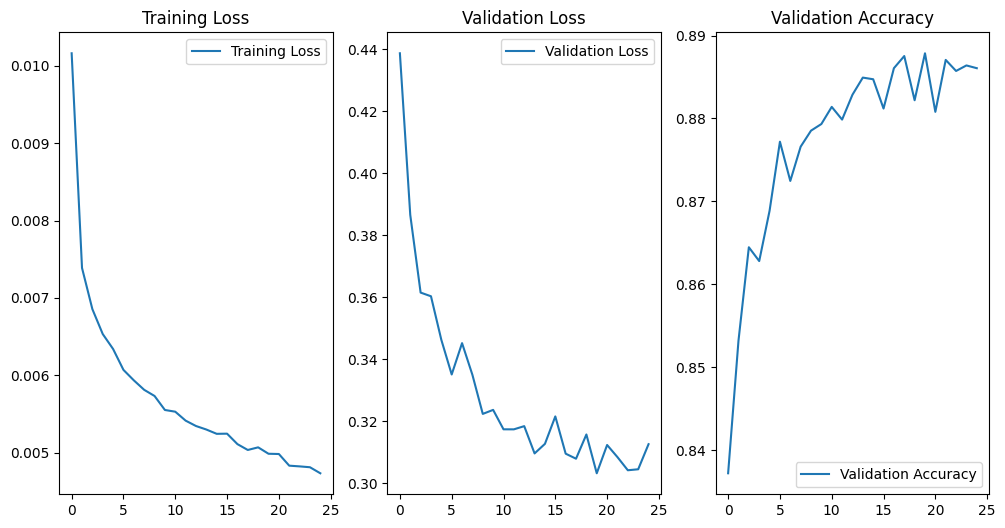

Average Validation Loss across folds: 0.3041553478291694
Average Validation Accuracy across folds: 0.8878666666666667
--------------------------------
Finished FOLD 0
--------------------------------
FOLD 1
--------------------------------
Epoch 1/100 - Loss: 0.0102, Val Loss: 0.4408, Val Accuracy: 0.8400
Epoch 2/100 - Loss: 0.0075, Val Loss: 0.4002, Val Accuracy: 0.8505
Epoch 3/100 - Loss: 0.0068, Val Loss: 0.3707, Val Accuracy: 0.8677
Epoch 4/100 - Loss: 0.0066, Val Loss: 0.3751, Val Accuracy: 0.8635
Epoch 5/100 - Loss: 0.0063, Val Loss: 0.3623, Val Accuracy: 0.8673
Epoch 6/100 - Loss: 0.0062, Val Loss: 0.3423, Val Accuracy: 0.8753
Epoch 7/100 - Loss: 0.0059, Val Loss: 0.3427, Val Accuracy: 0.8754
Epoch 8/100 - Loss: 0.0058, Val Loss: 0.3425, Val Accuracy: 0.8767
Epoch 9/100 - Loss: 0.0058, Val Loss: 0.3278, Val Accuracy: 0.8814
Epoch 10/100 - Loss: 0.0056, Val Loss: 0.3278, Val Accuracy: 0.8817
Epoch 11/100 - Loss: 0.0056, Val Loss: 0.3329, Val Accuracy: 0.8795
Epoch 12/100 - Loss: 

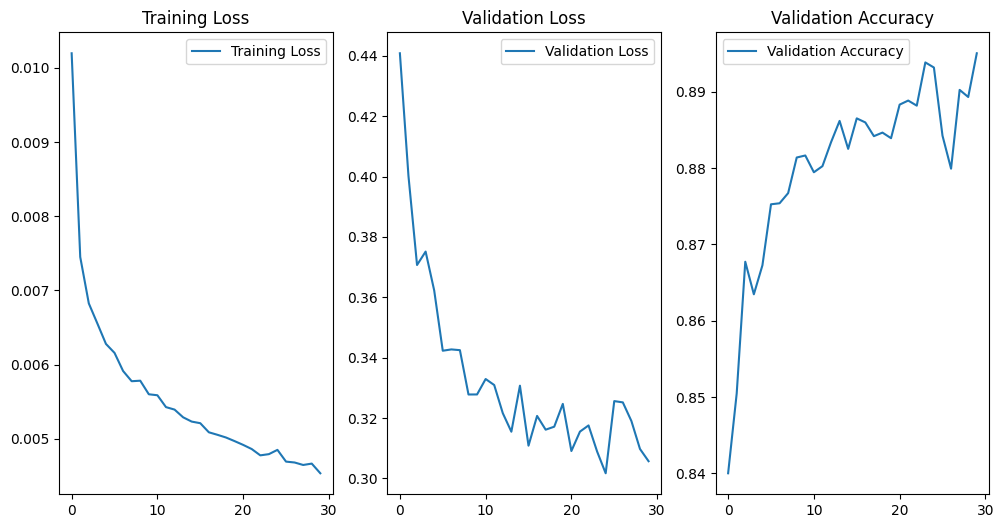

Average Validation Loss across folds: 0.30303091040634095
Average Validation Accuracy across folds: 0.8905333333333334
--------------------------------
Finished FOLD 1
--------------------------------
FOLD 2
--------------------------------
Epoch 1/100 - Loss: 0.0101, Val Loss: 0.4239, Val Accuracy: 0.8476
Epoch 2/100 - Loss: 0.0074, Val Loss: 0.3951, Val Accuracy: 0.8584
Epoch 3/100 - Loss: 0.0069, Val Loss: 0.3622, Val Accuracy: 0.8667
Epoch 4/100 - Loss: 0.0066, Val Loss: 0.3618, Val Accuracy: 0.8703
Epoch 5/100 - Loss: 0.0063, Val Loss: 0.3505, Val Accuracy: 0.8724
Epoch 6/100 - Loss: 0.0063, Val Loss: 0.3495, Val Accuracy: 0.8761
Epoch 7/100 - Loss: 0.0060, Val Loss: 0.3389, Val Accuracy: 0.8799
Epoch 8/100 - Loss: 0.0059, Val Loss: 0.3376, Val Accuracy: 0.8791
Epoch 9/100 - Loss: 0.0058, Val Loss: 0.3334, Val Accuracy: 0.8809
Epoch 10/100 - Loss: 0.0057, Val Loss: 0.3264, Val Accuracy: 0.8831
Epoch 11/100 - Loss: 0.0055, Val Loss: 0.3250, Val Accuracy: 0.8833
Epoch 12/100 - Loss:

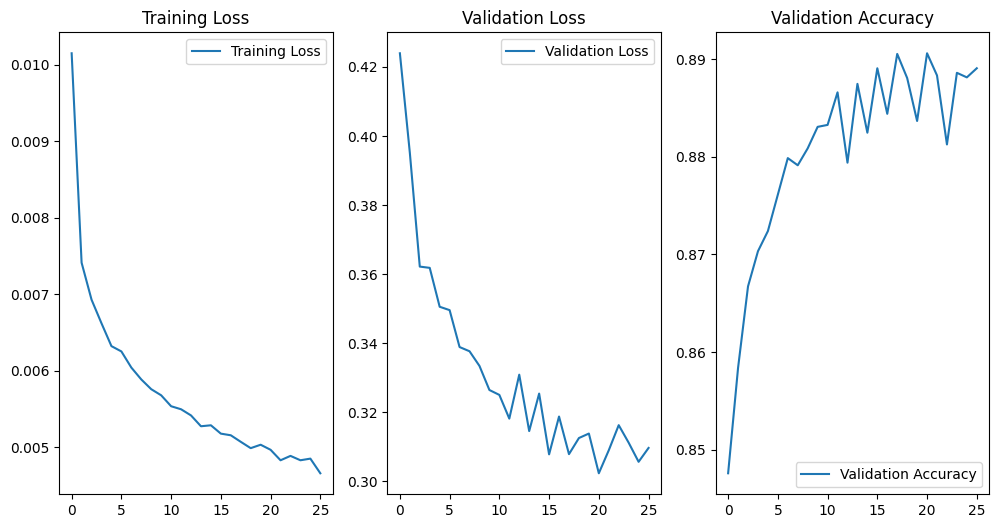

Average Validation Loss across folds: 0.3031931030412092
Average Validation Accuracy across folds: 0.8905555555555557
--------------------------------
Finished FOLD 2
--------------------------------
FOLD 3
--------------------------------
Epoch 1/100 - Loss: 0.0102, Val Loss: 0.4590, Val Accuracy: 0.8276
Epoch 2/100 - Loss: 0.0074, Val Loss: 0.3938, Val Accuracy: 0.8553
Epoch 3/100 - Loss: 0.0068, Val Loss: 0.3764, Val Accuracy: 0.8630
Epoch 4/100 - Loss: 0.0065, Val Loss: 0.3597, Val Accuracy: 0.8689
Epoch 5/100 - Loss: 0.0063, Val Loss: 0.3629, Val Accuracy: 0.8644
Epoch 6/100 - Loss: 0.0061, Val Loss: 0.3504, Val Accuracy: 0.8704
Epoch 7/100 - Loss: 0.0059, Val Loss: 0.3478, Val Accuracy: 0.8666
Epoch 8/100 - Loss: 0.0057, Val Loss: 0.3447, Val Accuracy: 0.8745
Epoch 9/100 - Loss: 0.0057, Val Loss: 0.3512, Val Accuracy: 0.8686
Epoch 10/100 - Loss: 0.0056, Val Loss: 0.3322, Val Accuracy: 0.8759
Epoch 11/100 - Loss: 0.0055, Val Loss: 0.3250, Val Accuracy: 0.8819
Epoch 12/100 - Loss: 

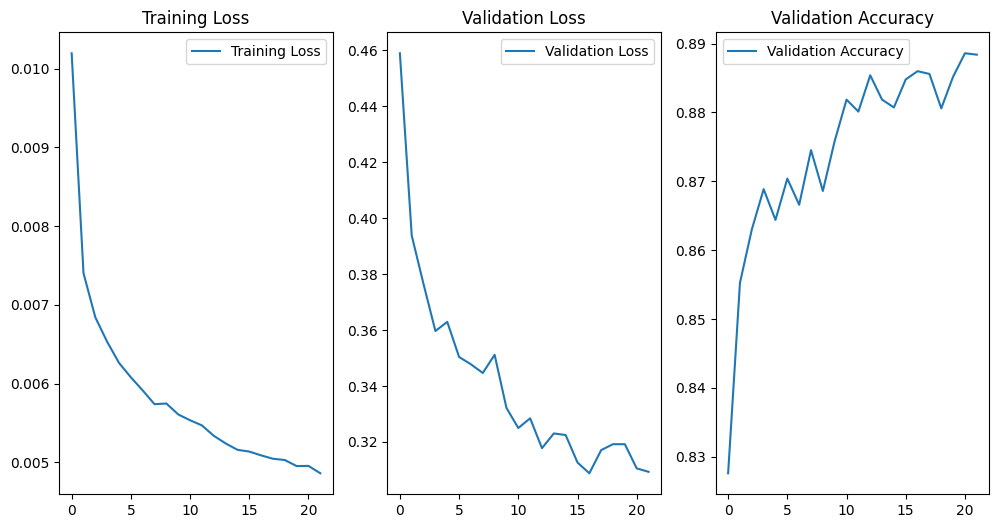

Average Validation Loss across folds: 0.3047214560686274
Average Validation Accuracy across folds: 0.8894166666666667
--------------------------------
Finished FOLD 3
--------------------------------


In [47]:
# train model
training_model_kfold(k_folds=4, dataset=training_data, model_fn=model_fn, loss_fn=nn.CrossEntropyLoss(), optimizer_name="Adam", lr=0.001, l1_reg=0, l2_reg=0, num_epochs=100, device='cpu', plot=True)

In [9]:
# test model
def test(dataloader, model, loss_fn, device):
    # size of the dataset
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    # model to evaluation mode
    model.eval()
    test_loss, correct = 0, 0
    # no gradients during evaluation
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    # average loss
    test_loss /= num_batches 
    #  accuracy 
    correct /= size

    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

# load model
model = NeuralNetwork(input_size=28*28, layer_sizes=[512, 256], activation_funcs=['relu', 'relu'], dropout_rate=0.5)
# load the best model from disk
model.load_state_dict(torch.load("best_model_fold_2.pth"))
# test the model with cross-entropy loss
loss_fn = nn.CrossEntropyLoss()
# optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

test(test_dataloader, model, loss_fn, device)
print("Done!")

Test Error: 
 Accuracy: 88.3%, Avg loss: 0.331863 

Done!


## HW-2.4: Hyper-parameter tuning

* Keep detailed records of hyper-parameter choices and associated training & validation errors
* Think critically and visualize the results of the search as needed

* **Do each of these in a different sub-section of your notebook**
  
* **Explore hyper-parameter choice-0**
  * for hidden activation=Relu, hidden layers = [32,32], optimizer=adam
  * Vary the learning rate via a grid search pattern
  * Plot training and validation error as a function of the learning rate
  * Repeat this exercise for both random and Xavier weight initialization 

* **Explore hyper-parameter choice-1**
  * for hidden activation=relu, hidden layers = [64,64], optimizer=adam
  * Vary L1 and L2 in a 10x10 grid search (without dropout) 
  * Plot validation and training error as a function of L1 and L2 regularization in a 2D heatmap 
  * Plot the ratio (or difference) of validation to training error as a function of L1 and L2 regularization in a 2D heatmap 

* **Explore hyper-parameter choice-2**
  * for hidden activation=sigmoid, hidden layers = [96,96,96], optimizer=**rmsprop**
  * Vary drop-out parameter in a 1x10 grid search (without L1 or L2 regularization) 
  * Plot training and validation error as a function of dropout rate  
  * Plot the ratio (or difference) of validation to training error as a function of dropout rate  

* **Explore hyper-parameter choice-3:**
  * for hidden activation=relu, hidden layers = [96,96,96], optimizer=**adam**
  * Vary drop-out parameter in a 1x10 grid search (without L1 or L2 regularization) 
  * Plot training and validation as a function of dropout rate  
  * Plot the ratio (or difference) of validation to training error as a function of dropout rate  

* `Optional` Systematically search for the best regularization parameters choice (3D search) using random search algorithm 
  * (https://en.wikipedia.org/wiki/Random_search)[https://en.wikipedia.org/wiki/Random_search]
  * Try to see how deep you can get the ANN (max hidden layers) without suffering from the vanishing gradient effect  
  
* `Final fit`
  * At the very end, select a best fit model and report, training, validation, and test errors at the very end
  * Make sure your "plotting variable=True" when for the final training
  

## Choice 0:
  * for hidden activation=Relu, hidden layers = [32,32], optimizer=adam
  * Vary the learning rate via a grid search pattern
  * Plot training and validation error as a function of the learning rate
  * Repeat this exercise for both random and Xavier weight initialization 

Due to the long runtimes, I will only do grid search of learning rate 0.001, 0.01, 0.1.

In [59]:
# model with random weight
def model_fn_random_init():
    return NeuralNetwork(input_size=28*28, layer_sizes=[32, 32], activation_funcs=['relu', 'relu'], dropout_rate=0.5, weight_init='random')
# model with xavier weight
def model_fn_xavier_init():
    return NeuralNetwork(input_size=28*28, layer_sizes=[32, 32], activation_funcs=['relu', 'relu'], dropout_rate=0.5, weight_init='xavier')

Experiment with Random Initialization
Training with learning rate: 0.1
FOLD 0
--------------------------------
Epoch 1/100 - Loss: 0.0375, Val Loss: 2.3139, Val Accuracy: 0.0960
Epoch 2/100 - Loss: 0.0362, Val Loss: 2.3122, Val Accuracy: 0.0971
Epoch 3/100 - Loss: 0.0362, Val Loss: 2.3053, Val Accuracy: 0.0988
Epoch 4/100 - Loss: 0.0362, Val Loss: 2.3100, Val Accuracy: 0.1036
Epoch 5/100 - Loss: 0.0362, Val Loss: 2.3114, Val Accuracy: 0.0991
Epoch 6/100 - Loss: 0.0362, Val Loss: 2.3119, Val Accuracy: 0.0995
Epoch 7/100 - Loss: 0.0362, Val Loss: 2.3113, Val Accuracy: 0.1015
Stopping early at epoch 8
--------------------------------
Finished FOLD 0
--------------------------------
FOLD 1
--------------------------------
Epoch 1/100 - Loss: 0.0368, Val Loss: 2.3172, Val Accuracy: 0.1008
Epoch 2/100 - Loss: 0.0362, Val Loss: 2.3112, Val Accuracy: 0.1008
Epoch 3/100 - Loss: 0.0363, Val Loss: 2.3100, Val Accuracy: 0.0991
Epoch 4/100 - Loss: 0.0362, Val Loss: 2.3174, Val Accuracy: 0.0991
Epoc

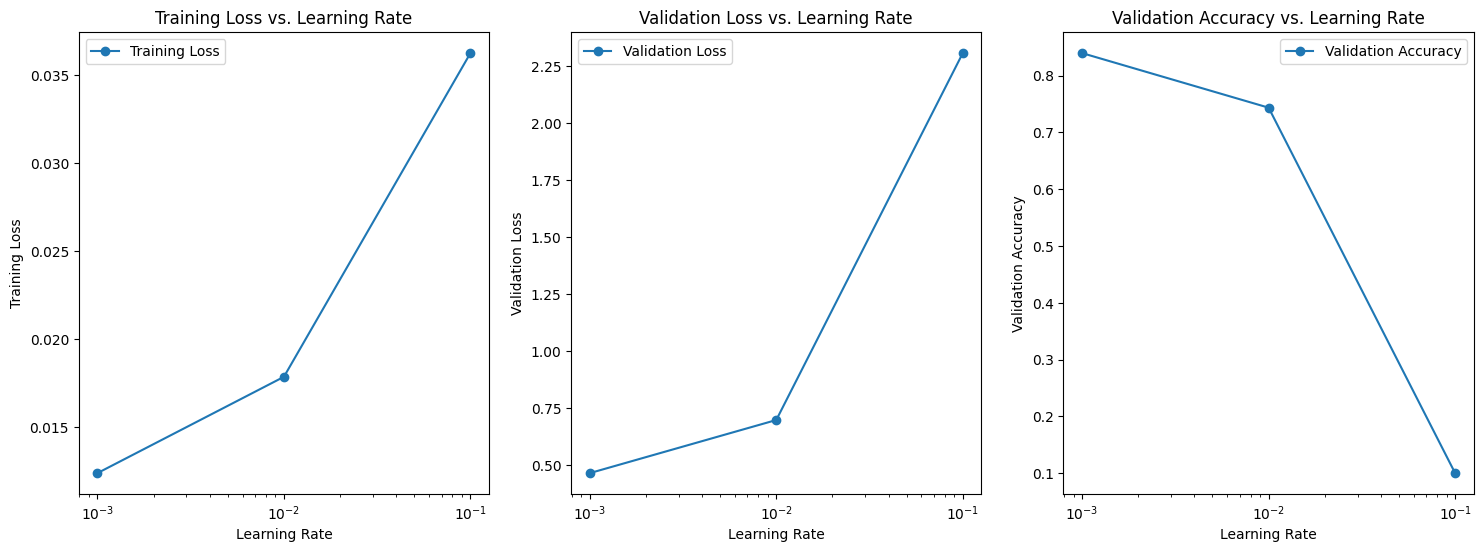

Experiment with Xavier Initialization
Training with learning rate: 0.1
FOLD 0
--------------------------------
Epoch 1/100 - Loss: 0.0370, Val Loss: 2.3088, Val Accuracy: 0.0997
Epoch 2/100 - Loss: 0.0362, Val Loss: 2.3065, Val Accuracy: 0.1003
Epoch 3/100 - Loss: 0.0362, Val Loss: 2.3103, Val Accuracy: 0.0984
Epoch 4/100 - Loss: 0.0362, Val Loss: 2.3067, Val Accuracy: 0.1007
Epoch 5/100 - Loss: 0.0362, Val Loss: 2.3086, Val Accuracy: 0.1037
Epoch 6/100 - Loss: 0.0361, Val Loss: 2.3135, Val Accuracy: 0.0984
Stopping early at epoch 7
--------------------------------
Finished FOLD 0
--------------------------------
FOLD 1
--------------------------------
Epoch 1/100 - Loss: 0.0371, Val Loss: 2.3130, Val Accuracy: 0.1010
Epoch 2/100 - Loss: 0.0362, Val Loss: 2.3127, Val Accuracy: 0.0974
Epoch 3/100 - Loss: 0.0362, Val Loss: 2.3070, Val Accuracy: 0.1010
Epoch 4/100 - Loss: 0.0362, Val Loss: 2.3063, Val Accuracy: 0.0974
Epoch 5/100 - Loss: 0.0362, Val Loss: 2.3164, Val Accuracy: 0.0949
Epoc

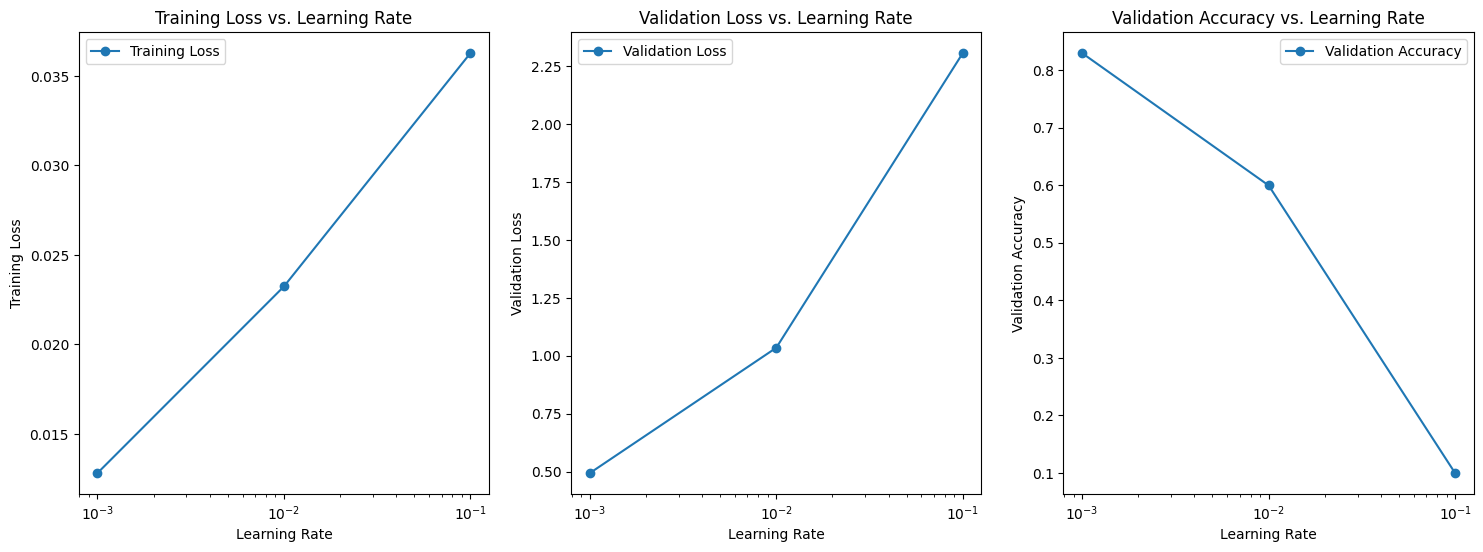

In [61]:
def mod_by_lr(learning_rates, k_folds, dataset, model_fn, loss_fn, optimizer_name, l1_reg, l2_reg, num_epochs=100, device='cpu', patience=5):
    lr_performance = {'lr': [], 'train_loss': [], 'val_loss': [], 'val_accuracy': []}
    
    for lr in learning_rates:
        print(f"Training with learning rate: {lr}")
        val_loss, val_accuracy, train_loss = training_model_kfold(k_folds=k_folds, dataset=dataset, model_fn=model_fn, loss_fn=loss_fn, optimizer_name=optimizer_name, lr=lr, l1_reg=l1_reg, l2_reg=l2_reg, num_epochs=num_epochs, device=device, plot=False, patience=patience)
        
        lr_performance['lr'].append(lr)
        lr_performance['train_loss'].append(train_loss)
        lr_performance['val_loss'].append(val_loss)
        lr_performance['val_accuracy'].append(val_accuracy)
    
    # Plotting performance as a function of learning rate
    plt.figure(figsize=(18, 6))
    
    plt.subplot(1, 3, 1)
    plt.plot(lr_performance['lr'], lr_performance['train_loss'], marker='o', linestyle='-', label='Training Loss')
    plt.title('Training Loss vs. Learning Rate')
    plt.xlabel('Learning Rate')
    plt.ylabel('Training Loss')
    plt.xscale('log')
    plt.legend()
    
    plt.subplot(1, 3, 2)
    plt.plot(lr_performance['lr'], lr_performance['val_loss'], marker='o', linestyle='-', label='Validation Loss')
    plt.title('Validation Loss vs. Learning Rate')
    plt.xlabel('Learning Rate')
    plt.ylabel('Validation Loss')
    plt.xscale('log')
    plt.legend()
    
    plt.subplot(1, 3, 3)
    plt.plot(lr_performance['lr'], lr_performance['val_accuracy'], marker='o', linestyle='-', label='Validation Accuracy')
    plt.title('Validation Accuracy vs. Learning Rate')
    plt.xlabel('Learning Rate')
    plt.ylabel('Validation Accuracy')
    plt.xscale('log')
    plt.legend()
    
    plt.show()


learning_rates = [0.1, 0.01, 0.001]

print("Experiment with Random Initialization")
mod_by_lr(learning_rates, k_folds=4, dataset=training_data, model_fn=model_fn_random_init, loss_fn=nn.CrossEntropyLoss(), optimizer_name="Adam", l1_reg=0, l2_reg=0, num_epochs=100, device='cpu', patience=5)

print("Experiment with Xavier Initialization")
mod_by_lr(learning_rates, k_folds=4, dataset=training_data, model_fn=model_fn_xavier_init, loss_fn=nn.CrossEntropyLoss(), optimizer_name="Adam", l1_reg=0, l2_reg=0, num_epochs=100, device='cpu', patience=5)

## Choice 1:
  * for hidden activation=relu, hidden layers = [64,64], optimizer=adam
  * Vary L1 and L2 in a 10x10 grid search (without dropout) 
  * Plot validation and training error as a function of L1 and L2 regularization in a 2D heatmap 
  * Plot the ratio (or difference) of validation to training error as a function of L1 and L2 regularization in a 2D heatmap 

### Note:
I will do a 5 by 5 grid search instead of a 10 by 10 grid search as the runtimes are very long and the results are similar. Professor James said that it was okay to do so. The cell not ran shows the code for a 10 by 10 grid search and the second one shows the code for a 5 by 5 grid search.

In [ ]:
# 10 by 10 grid search (not run)
# ranges for L1 and L2
l1_range = np.logspace(-4, -1, 10)
l2_range = np.logspace(-4, -1, 10)

# store results
results1 = []
# loop through the grid
for l1 in l1_range:
    for l2 in l2_range:
        print(f"Training with L1: {l1}, L2: {l2}")
        # train model
        avg_train_loss, avg_val_loss, avg_val_accuracy = training_model_kfold(
            model_fn=model_fn,
            k_folds=4,
            num_epochs=100,
            dataset=training_data,  
            loss_fn=nn.CrossEntropyLoss(),
            optimizer_name="Adam",
            lr=0.01,  
            l1_reg=l1,
            l2_reg=l2,
            device=device,
            patience=4,
            plot=False)
        
        # store results
        results1.append({
            'l1': l1,
            'l2': l2,
            'train_loss': avg_train_loss,
            'val_loss': avg_val_loss,
            'val_accuracy': avg_val_accuracy})

In [27]:
# 5 by 5 grid search 
# Define ranges for L1 and L2 
l1_range = np.logspace(-4, -1, 5) 
l2_range = np.logspace(-4, -1, 5) 

results1 = []

for l1 in l1_range:
    for l2 in l2_range:
        print(f"Training with L1: {l1}, L2: {l2}")
        
        avg_train_loss, avg_val_loss, avg_val_accuracy = training_model_kfold(
            model_fn=model_fn,
            k_folds=2,
            num_epochs=100,
            dataset=training_data,
            loss_fn=nn.CrossEntropyLoss(),
            optimizer_name="Adam",
            lr=0.01,  
            l1_reg=l1,
            l2_reg=l2,
            num_epochs=100,
            device=device,
            patience=4,
            plot=False)
        
        results1.append({
            'l1': l1,
            'l2': l2,
            'train_loss': avg_train_loss,
            'val_loss': avg_val_loss,
            'val_accuracy': avg_val_accuracy})

results_choice_1 = pd.DataFrame(results1)
results_choice_1.to_csv('results1.csv', index=False)
print(results_choice_1)

Training with L1: 0.0001, L2: 0.0001
FOLD 0
--------------------------------
Epoch 1/100 - Loss: 0.0380, Val Loss: 0.7429, Val Accuracy: 0.7243
Epoch 2/100 - Loss: 0.0431, Val Loss: 0.7548, Val Accuracy: 0.6858
Epoch 3/100 - Loss: 0.0430, Val Loss: 0.7459, Val Accuracy: 0.6887
Epoch 4/100 - Loss: 0.0460, Val Loss: 0.6938, Val Accuracy: 0.7083
Epoch 5/100 - Loss: 0.0443, Val Loss: 0.7786, Val Accuracy: 0.6976
Epoch 6/100 - Loss: 0.0438, Val Loss: 0.9246, Val Accuracy: 0.6295
Epoch 7/100 - Loss: 0.0459, Val Loss: 0.7116, Val Accuracy: 0.7470
Stopping early at epoch 8
--------------------------------
Finished FOLD 0
--------------------------------
FOLD 1
--------------------------------
Epoch 1/100 - Loss: 0.0377, Val Loss: 0.7237, Val Accuracy: 0.6817
Epoch 2/100 - Loss: 0.0434, Val Loss: 0.6957, Val Accuracy: 0.7262
Epoch 3/100 - Loss: 0.0443, Val Loss: 0.7128, Val Accuracy: 0.7239
Epoch 4/100 - Loss: 0.0447, Val Loss: 0.7870, Val Accuracy: 0.7103
Epoch 5/100 - Loss: 0.0448, Val Loss: 

In [45]:
# ordered them wrong, so fixing the column names
results_choice_1.rename(columns={'train_loss': 'avg_val_loss'}, inplace=True)
results_choice_1.rename(columns={'val_loss': 'average_val_accuracy'}, inplace=True)
results_choice_1.rename(columns={'val_accuracy': 'average_train_loss'}, inplace=True)

# save results_df1 to csv
results_choice_1.to_csv('results/results_choice_1.csv')

In [47]:
# Display results
results_choice_1

,l1,l2,average_val_loss,average_val_accuracy,average_train_loss
0,0.000100,0.000100,0.694800,0.717250,0.043452
1,0.000100,0.000562,0.709761,0.714033,0.039795
2,0.000100,0.003162,0.770717,0.707150,0.031289
3,0.000100,0.017783,0.933120,0.646633,0.024251
4,0.000100,0.100000,1.385864,0.447433,0.026379
5,0.000562,0.000100,0.694739,0.733000,0.056297
6,0.000562,0.000562,0.749390,0.713900,0.053505
7,0.000562,0.003162,0.777330,0.720000,0.046358
8,0.000562,0.017783,0.913481,0.667833,0.036259
9,0.000562,0.100000,1.450749,0.383667,0.033569


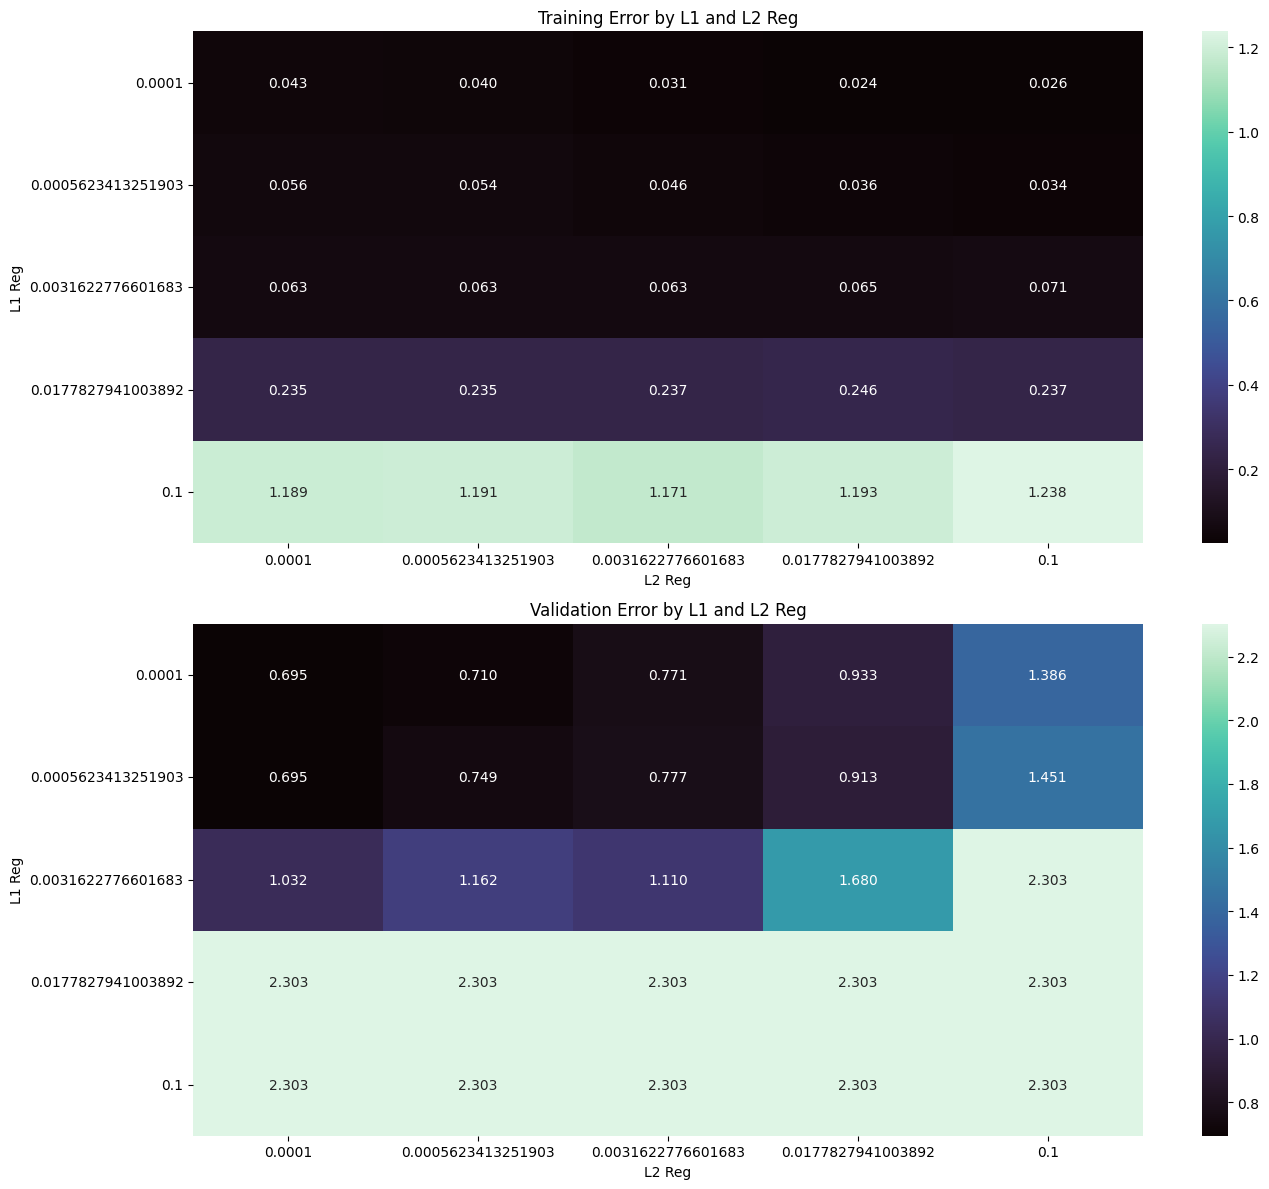

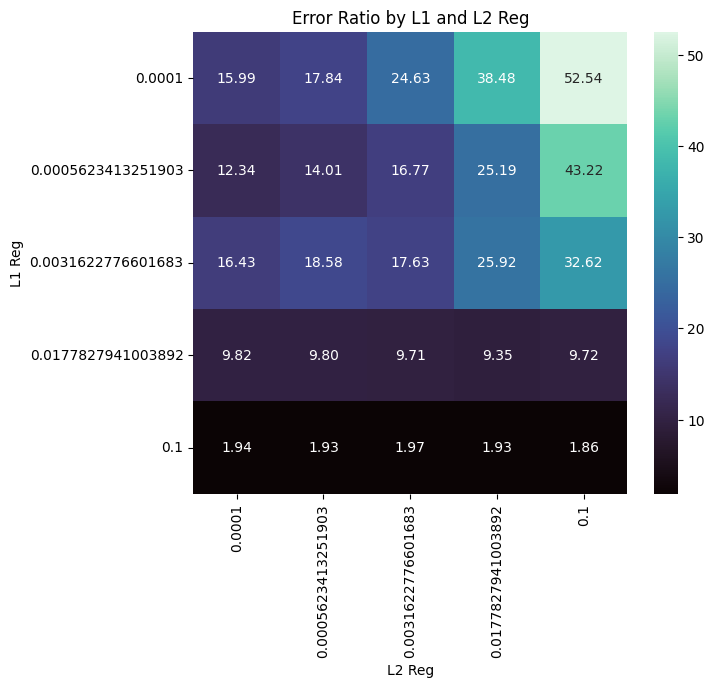

In [9]:
results_choice_1 = pd.read_csv('results/results_choice_1.csv')

# pivot the df for heatmap
train_loss_choice_1_data = results_choice_1.pivot(index='l1', columns='l2', values='average_train_loss')
val_loss_choice_1_data = results_choice_1.pivot(index='l1', columns='l2', values='average_val_loss')
# error ratio
error_ratio_choice_1_data = val_loss_choice_1_data / train_loss_choice_1_data

# Plot heatmaps
plt.figure(figsize=(14, 12))

# Training Error
plt.subplot(2, 1, 1)
sns.heatmap(train_loss_choice_1_data, annot=True, cmap='mako', fmt=".3f")
plt.title('Training Error by L1 and L2 Reg')
plt.xlabel('L2 Reg')
plt.ylabel('L1 Reg')

# Validation Error
plt.subplot(2, 1, 2)
sns.heatmap(val_loss_choice_1_data, annot=True, cmap='mako', fmt=".3f")
plt.title('Validation Error by L1 and L2 Reg')
plt.xlabel('L2 Reg')
plt.ylabel('L1 Reg')

# Show heatmaps
plt.tight_layout()
plt.show()

# Error Ratio
plt.figure(figsize=(7, 6))
sns.heatmap(error_ratio_choice_1_data, annot=True, cmap='mako', fmt=".2f")
plt.title('Error Ratio by L1 and L2 Reg')
plt.xlabel('L2 Reg')
plt.ylabel('L1 Reg')

# Save figure just in case
plt.savefig('error_ratio.png')
plt.show()


## Choice 2:
  * for hidden activation=sigmoid, hidden layers = [96,96,96], optimizer=**rmsprop**
  * Vary drop-out parameter in a 1x10 grid search (without L1 or L2 regularization) 
  * Plot training and validation error as a function of dropout rate  
  * Plot the ratio (or difference) of validation to training error as a function of dropout rate  

In [33]:
# model_fn2
def model_fn2(dropout_rate=0.0):
    return NeuralNetwork(input_size=28*28, layer_sizes=[96, 96, 96], activation_funcs=['sigmoid', 'sigmoid', 'sigmoid'], dropout_rate=dropout_rate)

dropout_rates = np.linspace(0.0, 0.9, 10) 

results2 = []

for dropout_rate in dropout_rates:
    print(f"Training with Dropout Rate: {dropout_rate}")
    avg_train_loss, avg_val_loss, avg_val_accuracy = training_model_kfold(
        k_folds=4,
        num_epochs=100,
        dataset=training_data,
        model_fn=lambda: model_fn2(dropout_rate=dropout_rate), 
        loss_fn=nn.CrossEntropyLoss(),
        optimizer_name="RMSProp",  # 
        lr=0.01,
        l1_reg=0, 
        l2_reg=0,
        device=device,
        patience=4,
        plot=False)
    
    results2.append({
        'dropout_rate': dropout_rate,
        'train_loss': avg_train_loss,
        'val_loss': avg_val_loss,
        'val_accuracy': avg_val_accuracy})

results_choice_2 = pd.DataFrame(results2)
print(results_choice_2)

Training with Dropout Rate: 0.0
FOLD 0
--------------------------------
Epoch 1/100 - Loss: 0.0149, Val Loss: 0.6797, Val Accuracy: 0.7635
Epoch 2/100 - Loss: 0.0080, Val Loss: 0.6904, Val Accuracy: 0.7749
Epoch 3/100 - Loss: 0.0071, Val Loss: 0.5336, Val Accuracy: 0.8151
Epoch 4/100 - Loss: 0.0067, Val Loss: 0.4747, Val Accuracy: 0.8267
Epoch 5/100 - Loss: 0.0065, Val Loss: 0.4366, Val Accuracy: 0.8459
Epoch 6/100 - Loss: 0.0063, Val Loss: 0.4410, Val Accuracy: 0.8434
Epoch 7/100 - Loss: 0.0061, Val Loss: 0.4566, Val Accuracy: 0.8116
Epoch 8/100 - Loss: 0.0060, Val Loss: 0.4628, Val Accuracy: 0.8339
Epoch 9/100 - Loss: 0.0059, Val Loss: 0.4293, Val Accuracy: 0.8459
Epoch 10/100 - Loss: 0.0058, Val Loss: 0.5254, Val Accuracy: 0.8048
Epoch 11/100 - Loss: 0.0057, Val Loss: 0.3938, Val Accuracy: 0.8599
Epoch 12/100 - Loss: 0.0056, Val Loss: 0.4080, Val Accuracy: 0.8571
Epoch 13/100 - Loss: 0.0056, Val Loss: 0.4058, Val Accuracy: 0.8571
Epoch 14/100 - Loss: 0.0055, Val Loss: 0.4593, Val Ac

In [49]:
# rename columns as they were ordered wrong (fixing)
results_choice_2.rename(columns={'train_loss': 'average_val_loss'}, inplace=True)
results_choice_2.rename(columns={'val_loss': 'average_val_accuracy'}, inplace=True)
results_choice_2.rename(columns={'val_accuracy': 'average_train_loss'}, inplace=True)

# save results_df2 to csv
results_choice_2.to_csv('results/results_choice_2.csv')

In [50]:
# display results
results_choice_2

,dropout_rate,average_val_loss,average_val_accuracy,average_train_loss
0,0.0,0.399432,0.859883,0.006611
1,0.1,0.422701,0.848567,0.007496
2,0.2,0.383377,0.857933,0.007475
3,0.3,0.408441,0.851150,0.008318
4,0.4,0.412833,0.852450,0.008976
5,0.5,0.438444,0.846483,0.010086
6,0.6,0.496899,0.819167,0.011739
7,0.7,0.625273,0.749183,0.015652
8,0.8,1.018903,0.519367,0.021895
9,0.9,2.302982,0.102200,0.036298


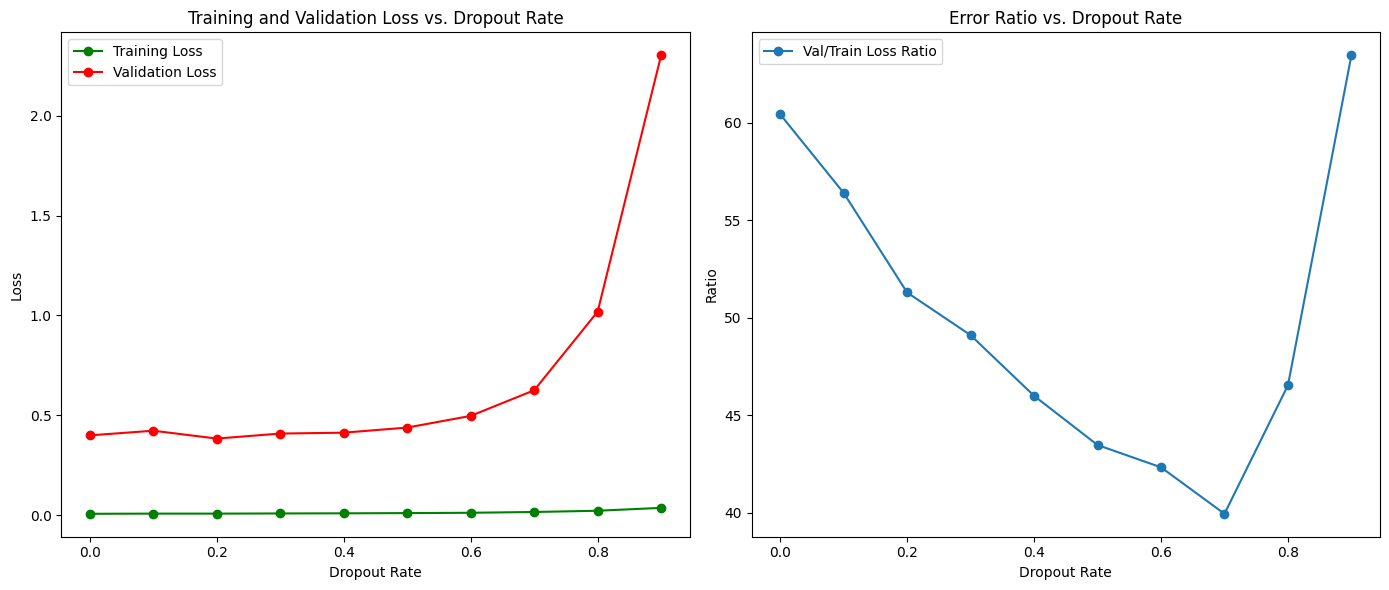

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

results_choice_2 = pd.read_csv('results/results_choice_2.csv')

# Plot
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(results_choice_2['dropout_rate'], results_choice_2['average_train_loss'], label='Training Loss', marker='o', color='green')
plt.plot(results_choice_2['dropout_rate'], results_choice_2['average_val_loss'], label='Validation Loss', marker='o', color='red')
plt.title('Training and Validation Loss vs. Dropout Rate')
plt.xlabel('Dropout Rate')
plt.ylabel('Loss')
plt.legend()

# Plot
plt.subplot(1, 2, 2)
error_ratio = results_choice_2['average_val_loss'] / results_choice_2['average_train_loss']
plt.plot(results_choice_2['dropout_rate'], error_ratio, label='Val/Train Loss Ratio', marker='o')
plt.title('Error Ratio vs. Dropout Rate')
plt.xlabel('Dropout Rate')
plt.ylabel('Ratio')
plt.legend()

plt.tight_layout()
plt.show()

## Choice 3:
  * for hidden activation=relu, hidden layers = [96,96,96], optimizer=**adam**
  * Vary drop-out parameter in a 1x10 grid search (without L1 or L2 regularization) 
  * Plot training and validation as a function of dropout rate  
  * Plot the ratio (or difference) of validation to training error as a function of dropout rate  

In [36]:
def model_fn3(dropout_rate=0.0):
    return NeuralNetwork(input_size=28*28, layer_sizes=[96, 96, 96], activation_funcs=['relu', 'relu', 'relu'], dropout_rate=dropout_rate)

dropout_rates = np.linspace(0.0, 0.9, 10) 

results3 = []

for dropout_rate in dropout_rates:
    print(f"Training with Dropout Rate: {dropout_rate}")
    avg_train_loss, avg_val_loss, avg_val_accuracy = training_model_kfold(
        k_folds=2,
        num_epochs=100,
        dataset=training_data,
        model_fn=lambda: model_fn3(dropout_rate=dropout_rate),
        loss_fn=nn.CrossEntropyLoss(),
        optimizer_name="Adam",
        lr=0.01, 
        l1_reg=0,   
        l2_reg=0,
        device=device,
        patience=4,
        plot=False)
    
    results3.append({
        'dropout_rate': dropout_rate,
        'train_loss': avg_train_loss,
        'val_loss': avg_val_loss,
        'val_accuracy': avg_val_accuracy})

results_choice_3 = pd.DataFrame(results3)
print(results_choice_3)

Training with Dropout Rate: 0.0
FOLD 0
--------------------------------
Epoch 1/100 - Loss: 0.0098, Val Loss: 0.5491, Val Accuracy: 0.8206
Epoch 2/100 - Loss: 0.0070, Val Loss: 0.4296, Val Accuracy: 0.8517
Epoch 3/100 - Loss: 0.0065, Val Loss: 0.4732, Val Accuracy: 0.8323
Epoch 4/100 - Loss: 0.0062, Val Loss: 0.5201, Val Accuracy: 0.8206
Epoch 5/100 - Loss: 0.0060, Val Loss: 0.4274, Val Accuracy: 0.8539
Epoch 6/100 - Loss: 0.0059, Val Loss: 0.4200, Val Accuracy: 0.8551
Epoch 7/100 - Loss: 0.0057, Val Loss: 0.4063, Val Accuracy: 0.8614
Epoch 8/100 - Loss: 0.0057, Val Loss: 0.4160, Val Accuracy: 0.8585
Epoch 9/100 - Loss: 0.0056, Val Loss: 0.3955, Val Accuracy: 0.8626
Epoch 10/100 - Loss: 0.0057, Val Loss: 0.4452, Val Accuracy: 0.8545
Epoch 11/100 - Loss: 0.0053, Val Loss: 0.4184, Val Accuracy: 0.8596
Epoch 12/100 - Loss: 0.0053, Val Loss: 0.4096, Val Accuracy: 0.8604
Stopping early at epoch 13
--------------------------------
Finished FOLD 0
--------------------------------
FOLD 1
-----

In [52]:
# rename columns as they were ordered wrong (fixing)

results_choice_3.rename(columns={'train_loss': 'average_val_loss'}, inplace=True)
results_choice_3.rename(columns={'val_loss': 'average_val_accuracy'}, inplace=True)
results_choice_3.rename(columns={'val_accuracy': 'average_train_loss'}, inplace=True)

# save results_df3 to csv
results_choice_3.to_csv('results/results_choice_3.csv')

In [54]:
# display results
results_choice_3

,dropout_rate,average_val_loss,average_val_accuracy,average_train_loss
0,0.0,0.404410,0.859967,0.006408
1,0.1,0.434562,0.846133,0.008214
2,0.2,0.476113,0.829450,0.009961
3,0.3,0.544292,0.803483,0.012022
4,0.4,0.623171,0.767600,0.014555
5,0.5,0.758220,0.701117,0.018314
6,0.6,1.087235,0.568233,0.023683
7,0.7,1.570115,0.392367,0.031110
8,0.8,2.110628,0.183750,0.035786
9,0.9,2.302976,0.100233,0.036044


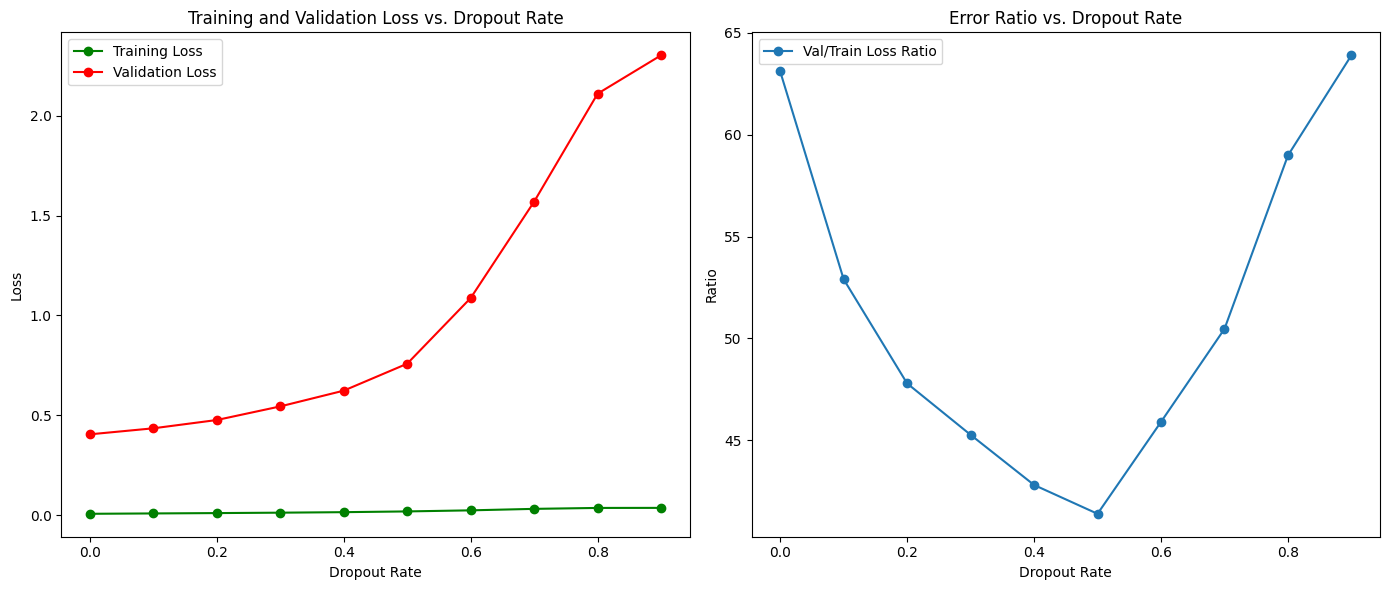

In [10]:
results_choice_3 = pd.read_csv('results/results_choice_3.csv')

# Plot
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(results_choice_3['dropout_rate'], results_choice_3['average_train_loss'], label='Training Loss', marker='o', color='green')
plt.plot(results_choice_3['dropout_rate'], results_choice_3['average_val_loss'], label='Validation Loss', marker='o', color='red')
plt.title('Training and Validation Loss vs. Dropout Rate')
plt.xlabel('Dropout Rate')
plt.ylabel('Loss')
plt.legend()

# Plot
plt.subplot(1, 2, 2)
error_ratio = results_choice_3['average_val_loss'] / results_choice_3['average_train_loss']
plt.plot(results_choice_3['dropout_rate'], error_ratio, label='Val/Train Loss Ratio', marker='o')
plt.title('Error Ratio vs. Dropout Rate')
plt.xlabel('Dropout Rate')
plt.ylabel('Ratio')
plt.legend()

plt.tight_layout()
plt.show()

## Final fit
  * At the very end, select a best fit model and report, training, validation, and test errors at the very end
  * Make sure your "plotting variable=True" when for the final training

My best model was the one with the following parameters: 
  * hidden activation=relu, hidden layers = [96,96,96], optimizer=adam, learning rate=0.001, L1=0, L2=0, dropout=0, weight initialization=random

FOLD 0
--------------------------------
Epoch 1/100 - Loss: 0.0098, Val Loss: 0.4877, Val Accuracy: 0.8215
Epoch 2/100 - Loss: 0.0065, Val Loss: 0.4001, Val Accuracy: 0.8525
Epoch 3/100 - Loss: 0.0058, Val Loss: 0.3777, Val Accuracy: 0.8595
Epoch 4/100 - Loss: 0.0055, Val Loss: 0.3714, Val Accuracy: 0.8619
Epoch 5/100 - Loss: 0.0051, Val Loss: 0.3436, Val Accuracy: 0.8764
Epoch 6/100 - Loss: 0.0049, Val Loss: 0.3358, Val Accuracy: 0.8739
Epoch 7/100 - Loss: 0.0046, Val Loss: 0.3054, Val Accuracy: 0.8892
Epoch 8/100 - Loss: 0.0044, Val Loss: 0.3431, Val Accuracy: 0.8756
Epoch 9/100 - Loss: 0.0042, Val Loss: 0.3166, Val Accuracy: 0.8860
Epoch 10/100 - Loss: 0.0041, Val Loss: 0.3118, Val Accuracy: 0.8873
Stopping early at epoch 11


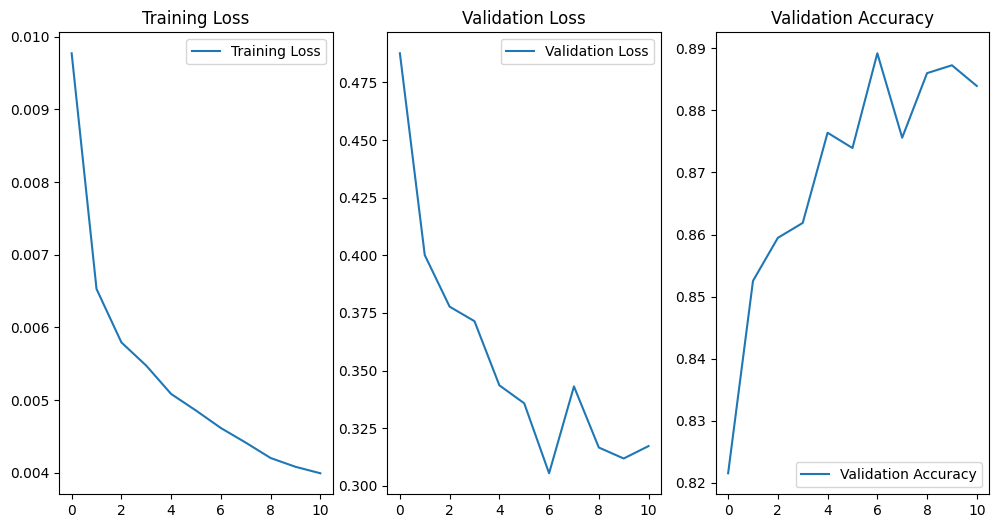

--------------------------------
Finished FOLD 0
--------------------------------
FOLD 1
--------------------------------
Epoch 1/100 - Loss: 0.0100, Val Loss: 0.4680, Val Accuracy: 0.8311
Epoch 2/100 - Loss: 0.0065, Val Loss: 0.4125, Val Accuracy: 0.8465
Epoch 3/100 - Loss: 0.0059, Val Loss: 0.3794, Val Accuracy: 0.8656
Epoch 4/100 - Loss: 0.0054, Val Loss: 0.3961, Val Accuracy: 0.8559
Epoch 5/100 - Loss: 0.0051, Val Loss: 0.3500, Val Accuracy: 0.8723
Epoch 6/100 - Loss: 0.0048, Val Loss: 0.3646, Val Accuracy: 0.8695
Epoch 7/100 - Loss: 0.0046, Val Loss: 0.3671, Val Accuracy: 0.8704
Epoch 8/100 - Loss: 0.0044, Val Loss: 0.3426, Val Accuracy: 0.8803
Epoch 9/100 - Loss: 0.0043, Val Loss: 0.3402, Val Accuracy: 0.8771
Epoch 10/100 - Loss: 0.0041, Val Loss: 0.3702, Val Accuracy: 0.8669
Epoch 11/100 - Loss: 0.0039, Val Loss: 0.3457, Val Accuracy: 0.8785
Epoch 12/100 - Loss: 0.0038, Val Loss: 0.3315, Val Accuracy: 0.8853
Epoch 13/100 - Loss: 0.0037, Val Loss: 0.3715, Val Accuracy: 0.8730
Epo

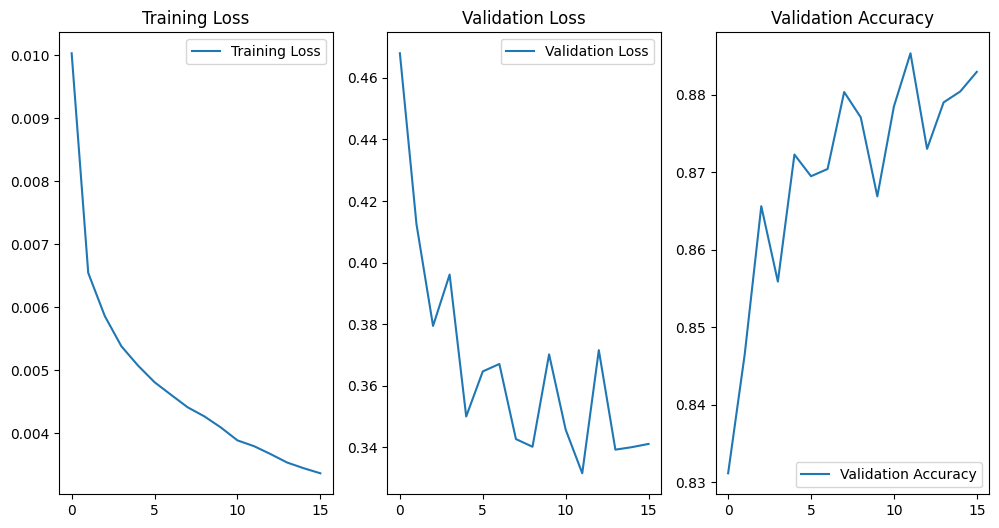

--------------------------------
Finished FOLD 1
--------------------------------
FOLD 2
--------------------------------
Epoch 1/100 - Loss: 0.0099, Val Loss: 0.4422, Val Accuracy: 0.8445
Epoch 2/100 - Loss: 0.0065, Val Loss: 0.3862, Val Accuracy: 0.8597
Epoch 3/100 - Loss: 0.0058, Val Loss: 0.3709, Val Accuracy: 0.8644
Epoch 4/100 - Loss: 0.0054, Val Loss: 0.3443, Val Accuracy: 0.8763
Epoch 5/100 - Loss: 0.0050, Val Loss: 0.3434, Val Accuracy: 0.8763
Epoch 6/100 - Loss: 0.0049, Val Loss: 0.3322, Val Accuracy: 0.8795
Epoch 7/100 - Loss: 0.0046, Val Loss: 0.3170, Val Accuracy: 0.8875
Epoch 8/100 - Loss: 0.0044, Val Loss: 0.3164, Val Accuracy: 0.8856
Epoch 9/100 - Loss: 0.0043, Val Loss: 0.3170, Val Accuracy: 0.8868
Epoch 10/100 - Loss: 0.0041, Val Loss: 0.3228, Val Accuracy: 0.8808
Epoch 11/100 - Loss: 0.0040, Val Loss: 0.3112, Val Accuracy: 0.8851
Epoch 12/100 - Loss: 0.0039, Val Loss: 0.3166, Val Accuracy: 0.8866
Epoch 13/100 - Loss: 0.0037, Val Loss: 0.3131, Val Accuracy: 0.8903
Epo

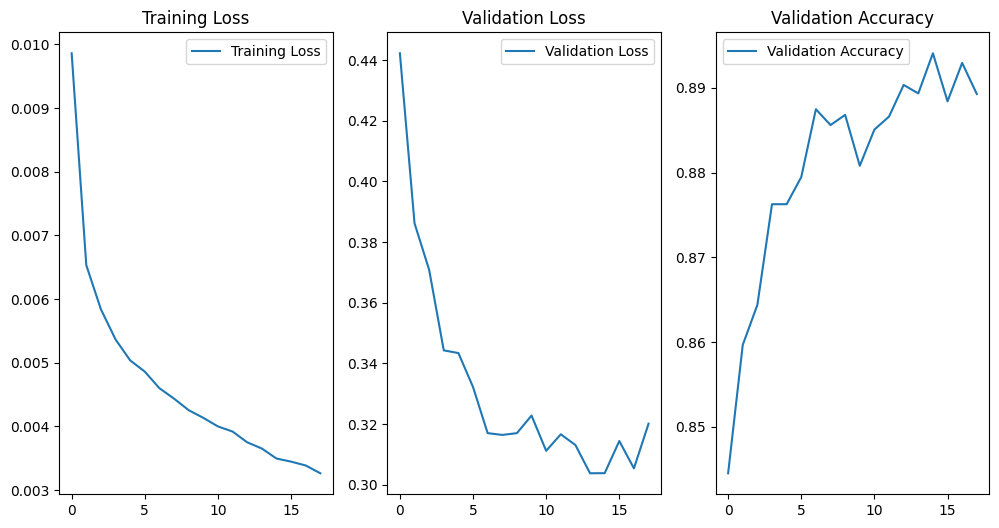

--------------------------------
Finished FOLD 2
--------------------------------
FOLD 3
--------------------------------
Epoch 1/100 - Loss: 0.0098, Val Loss: 0.4526, Val Accuracy: 0.8384
Epoch 2/100 - Loss: 0.0065, Val Loss: 0.4153, Val Accuracy: 0.8541
Epoch 3/100 - Loss: 0.0058, Val Loss: 0.3749, Val Accuracy: 0.8682
Epoch 4/100 - Loss: 0.0054, Val Loss: 0.3635, Val Accuracy: 0.8652
Epoch 5/100 - Loss: 0.0051, Val Loss: 0.3493, Val Accuracy: 0.8727
Epoch 6/100 - Loss: 0.0048, Val Loss: 0.3533, Val Accuracy: 0.8706
Epoch 7/100 - Loss: 0.0046, Val Loss: 0.3431, Val Accuracy: 0.8752
Epoch 8/100 - Loss: 0.0044, Val Loss: 0.3582, Val Accuracy: 0.8745
Epoch 9/100 - Loss: 0.0043, Val Loss: 0.3276, Val Accuracy: 0.8806
Epoch 10/100 - Loss: 0.0041, Val Loss: 0.3176, Val Accuracy: 0.8866
Epoch 11/100 - Loss: 0.0039, Val Loss: 0.3192, Val Accuracy: 0.8842
Epoch 12/100 - Loss: 0.0038, Val Loss: 0.3209, Val Accuracy: 0.8873
Epoch 13/100 - Loss: 0.0037, Val Loss: 0.3349, Val Accuracy: 0.8833
Epo

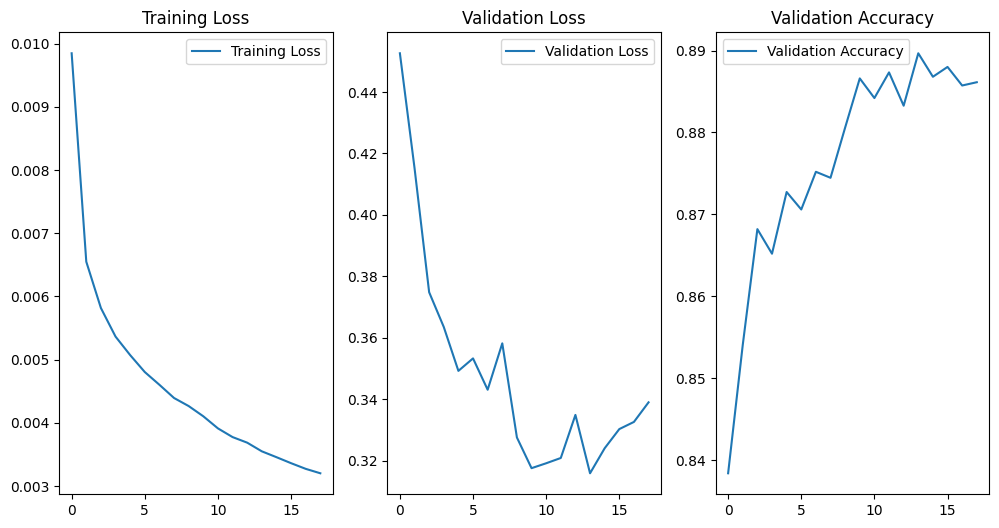

--------------------------------
Finished FOLD 3
--------------------------------
Validation Loss and Accuracy per Fold:
Fold 0: Validation Loss = 0.30621458574178373, Validation Accuracy = 0.8892
Fold 1: Validation Loss = 0.33166823387145994, Validation Accuracy = 0.8853333333333333
Fold 2: Validation Loss = 0.3046102743833623, Validation Accuracy = 0.8893333333333333
Fold 3: Validation Loss = 0.31593505687853124, Validation Accuracy = 0.8896666666666667
Average Validation Loss across folds: 0.3146070377187843
Average Validation Accuracy across folds: 0.8883833333333333
--------------------------------
K-fold Cross-validation completed.
   train_loss  val_loss  val_accuracy
0    0.004801  0.314607      0.888383


In [55]:
# Best model
def model_fn_final():
    return NeuralNetwork(input_size=28*28, layer_sizes=[96, 96, 96], activation_funcs=['relu', 'relu', 'relu'], dropout_rate=0)

final_results = []

avg_val_loss, avg_val_accuracy, avg_train_loss = training_model_kfold(k_folds=4, dataset=training_data, model_fn=model_fn_final, loss_fn=nn.CrossEntropyLoss(), optimizer_name="Adam", lr=0.001, l1_reg=0, l2_reg=0, num_epochs=100, device='cpu', plot=True, patience=4)

final_results.append({
        'train_loss': avg_train_loss,
        'val_loss': avg_val_loss,
        'val_accuracy': avg_val_accuracy
    })

final_results = pd.DataFrame(final_results)
print(final_results)

In [56]:
# save final_results_df to csv
final_results.to_csv('results/final_results.csv')

## Acruacy of my best model:

In [57]:
# Model evaluation
model = NeuralNetwork(input_size=28*28, layer_sizes=[96, 96, 96], activation_funcs=['relu', 'relu', 'relu'], dropout_rate=0)
model.load_state_dict(torch.load("best_model_fold_2.pth"))
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

test(test_dataloader, model, loss_fn, device)
print("Done!")

Test Error: 
 Accuracy: 88.2%, Avg loss: 0.337591 

Done!


# Bonus assignment 

`+5 bonus points`

`You DO NOT need to do this if you don't want to`

* Once the data is collected, this HW should be quite easy, since most of the code can be recycled from the labs & textbook. 

* Do this in a file called `bonus.ipynb`, have it save its results to a folder "data"

`Data collection`

* Develope a text based classification data-set:
* Use the Wikipedia API to search for articles to generate the data-set
* Select a set of highly different topics (i.e. labels), for example,
  * multi-class case: y=(pizza, oak_trees, basketball, ... , etc)=(0,1,2, ... , N-1)
  * You don't have to use these, you can use whatever labels you want
  * `Have AT LEAST 10 labels.` 
  * The more different the topics, the easier the classification task should be 
* Search for Wikipedia pages about these topics and harvest the text from the pages. 
* Do some basic text cleaning as needed. 
  * e.g. use the NLTK sentence tokenizer to break the text into sentences. 
  * Then form chunks of text that are five sentences long as your "inputs".
* The "label" for these chunks will be the search label used to find the text. 
* The data set will not be perfect. 
  * There will be chunks of text that are not related to the topic (i.e. noise). 
  * However that is just something we have to live with.
* **Important**: Always start small when writing & debugging THEN scale up. 
* The more chunks of text you have the better.
  * Save the text and labels to the same format used by the textbook, that way you can recycle your lab code seamlessly. 
* `Optional practice`: You can also "tag" each chunk of text with an associated "compound" sentiment score computed using the NLTK sentiment analysis. From this you can train a regression model in part-2. This is somewhat silly, and is just for educational purposes, since your using a model output to train another model. 

`Model training`

* Repeat the model training and hyper-parameter tuning exercise for MNIST, but with your text.